### [Exploratory Data Analysis (EDA) for Better Insights](https://medium.com/h7w/how-to-perform-exploratory-data-analysis-eda-for-better-insights-97752df41066)

In [1]:
!pip install --quiet ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 733.6 kB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

raw_data = 'https://github.com/ine-rmotr-curriculum/FreeCodeCamp-Pandas-Real-Life-Example/raw/refs/heads/master/data/sales_data.csv'

In [3]:
# Load dataset
df = pd.read_csv(raw_data)

# Preview sample
display(df.sample(20))

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
82516,2015-12-06,6,December,2015,36,Adults (35-64),M,Canada,British Columbia,Accessories,Tires and Tubes,Road Tire Tube,26,1,4,77,26,103
105489,2016-04-04,4,April,2016,21,Youth (<25),F,United States,California,Accessories,Tires and Tubes,Patch Kit/8 Patches,16,1,2,15,16,31
5710,2014-05-19,19,May,2014,26,Young Adults (25-34),M,France,Essonne,Accessories,Bottles and Cages,Water Bottle - 30 oz.,9,2,5,25,18,43
51252,2014-05-09,9,May,2014,23,Youth (<25),F,France,Moselle,Bikes,Mountain Bikes,"Mountain-200 Silver, 42",1,1266,2320,776,1266,2042
74038,2014-01-16,16,January,2014,23,Youth (<25),M,Canada,British Columbia,Clothing,Socks,"Racing Socks, M",5,3,9,30,15,45
26931,2016-03-29,29,March,2016,59,Adults (35-64),M,Australia,Victoria,Accessories,Fenders,Fender Set - Mountain,7,8,22,66,56,122
44138,2014-04-01,1,April,2014,31,Young Adults (25-34),F,France,Seine (Paris),Clothing,Jerseys,"Short-Sleeve Classic Jersey, L",27,42,54,62,1134,1196
33438,2013-09-24,24,September,2013,26,Young Adults (25-34),F,United Kingdom,England,Accessories,Helmets,"Sport-100 Helmet, Black",7,13,35,144,91,235
57663,2016-06-21,21,June,2016,41,Adults (35-64),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 46",3,1266,2320,3023,3798,6821
99166,2014-01-05,5,January,2014,22,Youth (<25),F,Germany,Saarland,Accessories,Tires and Tubes,Touring Tire,19,11,29,243,209,452


In [4]:
# Preview information
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

None

In [5]:
# Describe the dataset
display(df.describe())

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


In [6]:
# Count missing values
display(df.isnull().sum())

,0
Date,0
Day,0
Month,0
Year,0
Customer_Age,0
Age_Group,0
Customer_Gender,0
Country,0
State,0
Product_Category,0


In [7]:
# Count N/A values
display(df.isna().sum())

,0
Date,0
Day,0
Month,0
Year,0
Customer_Age,0
Age_Group,0
Customer_Gender,0
Country,0
State,0
Product_Category,0


In [8]:
# Rename a single column in place
df.rename(columns={'State': 'Region'}, inplace=True)

In [9]:
# Fill missing numerical columns with mean
df['Revenue'] = df['Revenue'].fillna(df['Revenue'].mean())

# Drop rows with too many missing values
df = df.dropna(thresh=3)

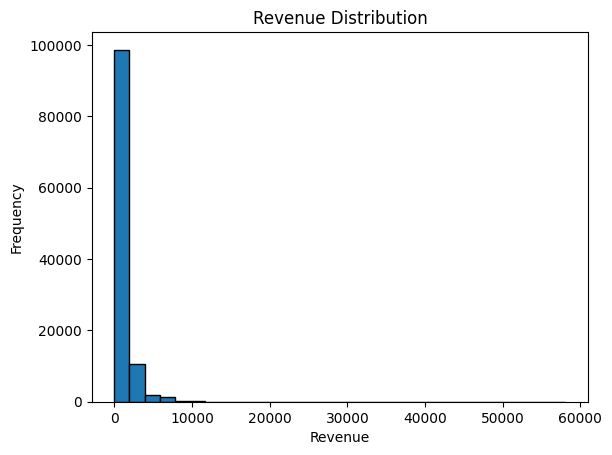

In [10]:
# Histogram for Revenue
plt.hist(df['Revenue'], bins=30, edgecolor="black")
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [11]:
# Value counts for categorical column
display(df['Region'].value_counts())

,count
Region,
California,22450
British Columbia,14116
England,13620
Washington,11264
New South Wales,10412
Victoria,6016
Oregon,5286
Queensland,5220
Saarland,2770


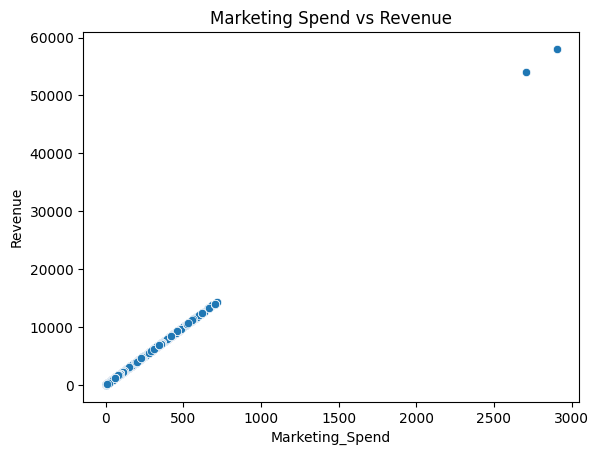

In [12]:
df["Marketing_Spend"] = df["Revenue"] * 0.05

# Scatter plot: Revenue vs Marketing Spend
sns.scatterplot(x="Marketing_Spend", y="Revenue", data=df)
plt.title("Marketing Spend vs Revenue")
plt.show()

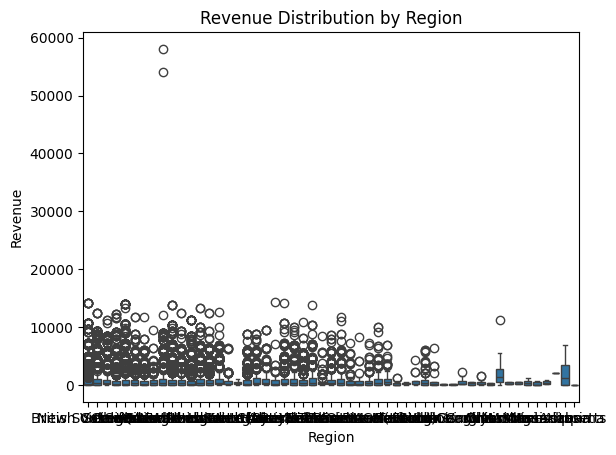

In [13]:
# Box plot: Revenue by Region
sns.boxplot(x="Region", y="Revenue", data=df)
plt.title("Revenue Distribution by Region")
plt.show()

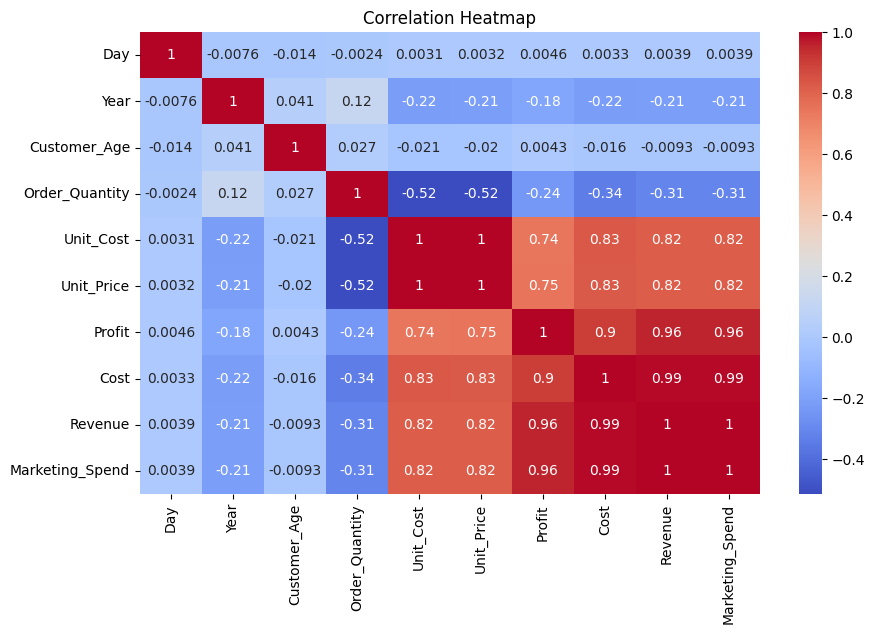

In [14]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

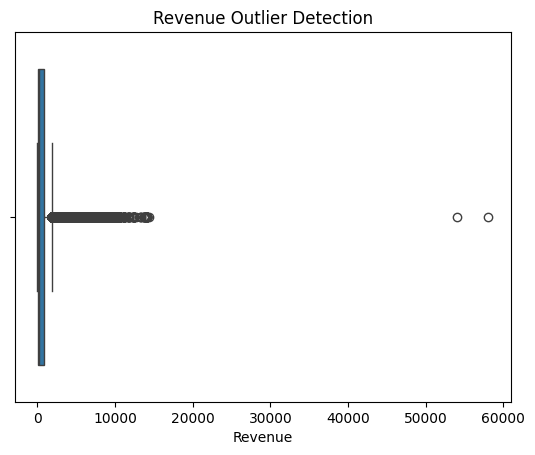

In [15]:
# Boxplot for outliers
sns.boxplot(x=df['Revenue'])
plt.title("Revenue Outlier Detection")
plt.show()

In [16]:
# Using IQR
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Revenue'] < (Q1 - 1.5 * IQR)) | (df['Revenue'] > (Q3 + 1.5 * IQR))]
display(outliers)

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,Region,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue,Marketing_Spend
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401,120.05
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088,104.40
8,2014-02-22,22,February,2014,35,Adults (35-64),M,Australia,Victoria,Accessories,Bike Racks,Hitch Rack - 4-Bike,22,45,120,1096,990,2086,104.30
9,2016-02-22,22,February,2016,35,Adults (35-64),M,Australia,Victoria,Accessories,Bike Racks,Hitch Rack - 4-Bike,21,45,120,1046,945,1991,99.55
30,2014-03-13,13,March,2014,48,Adults (35-64),F,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1476,900,2376,118.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112069,2016-02-27,27,February,2016,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",2,1482,2384,1613,2964,4577,228.85
112070,2014-06-13,13,June,2014,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",1,1482,2384,807,1482,2289,114.45
112071,2016-06-13,13,June,2016,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",2,1482,2384,1613,2964,4577,228.85
112072,2013-07-24,24,July,2013,52,Adults (35-64),M,Australia,Queensland,Clothing,Vests,"Touring-1000 Yellow, 50",27,1482,2384,14055,40014,54069,2703.45


In [17]:
# Create new feature: Profit Margin
df['Profit_Margin'] = (df['Revenue'] - df['Cost']) / df['Revenue']

# Create new feature: Month from Date
df['Month'] = pd.to_datetime(df['Date']).dt.month

display(df[['Revenue', 'Profit_Margin', 'Month']].head())

,Revenue,Profit_Margin,Month
0,950,0.621053,11
1,950,0.621053,11
2,2401,0.568930,3
3,2088,0.568966,3
4,418,0.569378,5


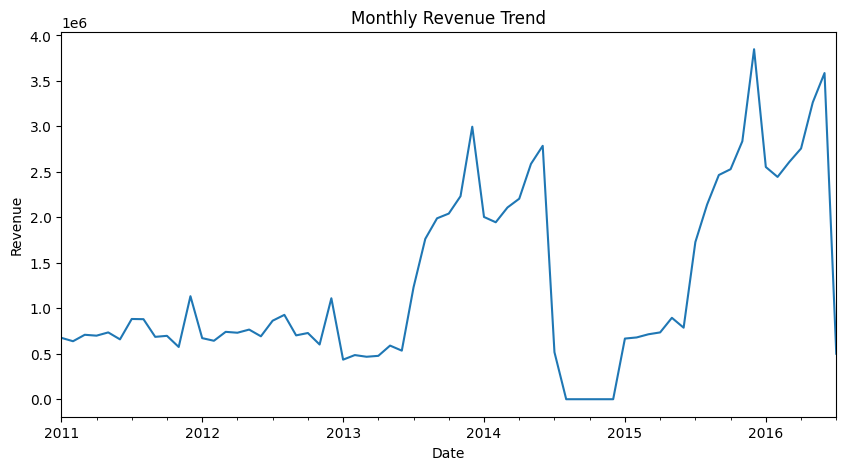

In [18]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Resample monthly
monthly_revenue = df['Revenue'].resample('M').sum()

monthly_revenue.plot(figsize=(10, 5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

In [19]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Sales Data EDA Report")
profile.to_file("/content/eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 19/19 [00:01<00:00, 10.76it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]